# 🎓 Masterclass en Data Science
## Ejercicio Práctico — Notebook SOLUCIÓN
### Predicción de Churn Bancario con Machine Learning

---
**Dataset:** Sintético (banco retail europeo, ~10.000 clientes)  
**Objetivo:** Clasificación binaria — predecir clientes con riesgo de churn  


In [1]:
# ── IMPORTS ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, f1_score, recall_score, precision_score,
                             roc_curve, precision_recall_curve, classification_report,
                             ConfusionMatrixDisplay, average_precision_score)
import xgboost as xgb
import shap

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = {'churn': '#D35400', 'no_churn': '#1A3A6B'}
print('✅ Imports correctos')

✅ Imports correctos


---
## PARTE 1 — Generación del dataset y calidad del dato
*(En la práctica real, aquí cargarías el CSV con `pd.read_csv`)*

In [2]:
# ── GENERACIÓN DEL DATASET SINTÉTICO ──────────────────────────────────────────
np.random.seed(42)
N = 10_000

# Variables base
credit_score    = np.random.randint(300, 851, N).astype(float)
country_raw     = np.random.choice(['France','Germany','Spain'], N, p=[0.50, 0.25, 0.25])
gender          = np.random.choice(['Male','Female'], N, p=[0.545, 0.455])
age             = np.random.normal(38.9, 10.5, N).clip(18, 92).round().astype(float)
tenure          = np.random.randint(0, 11, N).astype(float)
balance         = np.where(np.random.rand(N) < 0.29, 0,
                  np.random.normal(76_485, 62_397, N).clip(0, 250_000))
num_products    = np.random.choice([1,2,3,4], N, p=[0.50, 0.46, 0.025, 0.015])
has_credit_card = np.random.choice([0,1], N, p=[0.29, 0.71])
is_active       = np.random.choice([0,1], N, p=[0.485, 0.515])
salary          = np.random.uniform(11_580, 199_992, N)

# Target: churn (correlacionado con age, balance, is_active, num_products)
logit = (-2.8
         + 0.03 * (age - 38)
         + 0.6  * (country_raw == 'Germany').astype(float)
         - 0.5  * is_active
         + np.where(num_products >= 3, 1.2, 0)
         + 0.4  * (balance == 0).astype(float)
         - 0.3  * (gender == 'Female').astype(float)
         + np.random.normal(0, 0.5, N))
prob_churn = 1 / (1 + np.exp(-logit))
churned = (np.random.rand(N) < prob_churn).astype(int)

df = pd.DataFrame({
    'customer_id'     : 15_000_001 + np.arange(N),
    'credit_score'    : credit_score,
    'country'         : country_raw,
    'gender'          : gender,
    'age'             : age,
    'tenure'          : tenure,
    'balance'         : balance.round(2),
    'num_products'    : num_products,
    'has_credit_card' : has_credit_card,
    'is_active_member': is_active,
    'estimated_salary': salary.round(2),
    'churned'         : churned,
})

# ── INTRODUCIR ERRORES INTENCIONADOS ──────────────────────────────────────────
# 1. Nulos en credit_score (~5%) y age (~3%)
null_cs  = np.random.choice(N, int(N*0.05), replace=False)
null_age = np.random.choice(N, int(N*0.03), replace=False)
df.loc[null_cs,  'credit_score'] = np.nan
df.loc[null_age, 'age']          = np.nan

# 2. Duplicados parciales (~50)
dup_idx = np.random.choice(N, 50, replace=False)
df = pd.concat([df, df.iloc[dup_idx]], ignore_index=True)

# 3. Valores imposibles en age
df.loc[np.random.choice(df.index, 20), 'age'] = np.random.choice([150, 200, -5], 20)

# 4. Variantes de texto en country
mask = np.random.choice(df.index, 200, replace=False)
df.loc[mask, 'country'] = df.loc[mask, 'country'].str.lower()
mask2 = np.random.choice(df.index, 100, replace=False)
df.loc[mask2, 'country'] = df.loc[mask2, 'country'].str.upper()

# 5. Balances negativos
df.loc[np.random.choice(df.index, 30), 'balance'] = np.random.uniform(-5000, -1, 30).round(2)

print(f'Dataset creado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Churn rate base: {churned.mean():.1%}')
df.head()

Dataset creado: 10,050 filas × 12 columnas
Churn rate base: 7.0%


,customer_id,credit_score,country,gender,age,tenure,balance,num_products,has_credit_card,is_active_member,estimated_salary,churned
0,15000001,402.0,Spain,Female,42.0,10.0,132904.11,2,1,0,82034.69,0
1,15000002,735.0,Germany,Male,56.0,7.0,37633.67,2,0,1,82915.21,0
2,15000003,570.0,Germany,Female,28.0,6.0,31238.15,2,0,1,38751.40,0
3,15000004,406.0,France,Male,65.0,6.0,0.00,1,1,0,163684.52,0
4,15000005,371.0,Spain,Female,49.0,4.0,118313.87,1,0,1,128341.19,0


### 1.1 Inspección inicial

In [3]:
print('── SHAPE ──────────────────────────────────────────')
print(df.shape)

print('\n── DTYPES + NULL COUNT ────────────────────────────')
df.info()

print('\n── ESTADÍSTICOS ───────────────────────────────────')
df.describe(include='all').round(2)

── SHAPE ──────────────────────────────────────────
(10050, 12)

── DTYPES + NULL COUNT ────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10050 non-null  int64  
 1   credit_score      9546 non-null   float64
 2   country           10050 non-null  object 
 3   gender            10050 non-null  object 
 4   age               9751 non-null   float64
 5   tenure            10050 non-null  float64
 6   balance           10050 non-null  float64
 7   num_products      10050 non-null  int64  
 8   has_credit_card   10050 non-null  int64  
 9   is_active_member  10050 non-null  int64  
 10  estimated_salary  10050 non-null  float64
 11  churned           10050 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 942.3+ KB

── ESTADÍSTICOS ───────────────────────────────────

,customer_id,credit_score,country,gender,age,tenure,balance,num_products,has_credit_card,is_active_member,estimated_salary,churned
count,10050.00,9546.00,10050,10050,9751.00,10050.00,10050.00,10050.00,10050.00,10050.00,10050.00,10050.00
unique,NaN,NaN,9,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4919,5399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,15004995.91,575.29,NaN,NaN,39.07,4.99,56830.88,1.56,0.70,0.51,105985.45,0.07
std,2887.18,159.65,NaN,NaN,11.58,3.15,59837.66,0.61,0.46,0.50,54287.65,0.26
min,15000001.00,300.00,NaN,NaN,-5.00,0.00,-4675.01,1.00,0.00,0.00,11598.45,0.00
25%,15002496.25,436.00,NaN,NaN,32.00,2.00,0.00,1.00,0.00,0.00,58363.44,0.00
50%,15004992.50,573.00,NaN,NaN,39.00,5.00,43821.90,2.00,1.00,1.00,106277.22,0.00
75%,15007494.75,715.00,NaN,NaN,46.00,8.00,100176.04,2.00,1.00,1.00,153156.36,0.00


In [4]:
# ── REPORTE DE CALIDAD ────────────────────────────────────────────────────────
print('═'*55)
print('REPORTE DE CALIDAD DEL DATASET')
print('═'*55)

# Nulos
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
print('\n📋 VALORES NULOS:')
print(pd.DataFrame({'count': nulls[nulls>0], '%': null_pct[null_pct>0]}))

# Duplicados
n_dup = df.duplicated(subset=[c for c in df.columns if c != 'customer_id']).sum()
print(f'\n🔑 DUPLICADOS (excl. customer_id): {n_dup}')

# Variantes country
print('\n🌍 VARIANTES DE country:')
print(df['country'].value_counts())

# Valores imposibles
print(f"\n⚠️  age fuera de rango [18, 92]: {((df['age'] < 18) | (df['age'] > 100)).sum()}")
print(f"⚠️  balance negativo: {(df['balance'] < 0).sum()}")

═══════════════════════════════════════════════════════
REPORTE DE CALIDAD DEL DATASET
═══════════════════════════════════════════════════════

📋 VALORES NULOS:
              count     %
credit_score    504  5.01
age             299  2.98

🔑 DUPLICADOS (excl. customer_id): 43

🌍 VARIANTES DE country:
country
France     4919
Germany    2470
Spain      2362
france       85
germany      68
FRANCE       59
spain        46
GERMANY      24
SPAIN        17
Name: count, dtype: int64

⚠️  age fuera de rango [18, 92]: 20
⚠️  balance negativo: 30


### 1.2 Limpieza del dataset

In [5]:
df_clean = df.copy()

# 1. Normalizar country
df_clean['country'] = df_clean['country'].str.strip().str.title()
print('✅ country normalizado:', df_clean['country'].unique())

# 2. Eliminar duplicados (conservar primera ocurrencia)
n_before = len(df_clean)
df_clean.drop_duplicates(
    subset=[c for c in df_clean.columns if c != 'customer_id'],
    keep='first', inplace=True
)
print(f'✅ Duplicados eliminados: {n_before - len(df_clean)}')

# 3. Valores imposibles en age → NaN (serán imputados más adelante en el Pipeline)
impossible_age = (df_clean['age'] < 18) | (df_clean['age'] > 100)
df_clean.loc[impossible_age, 'age'] = np.nan
print(f'✅ age imposibles → NaN: {impossible_age.sum()}')

# 4. Balances negativos → NaN (probablemente error de captura)
neg_bal = df_clean['balance'] < 0
df_clean.loc[neg_bal, 'balance'] = np.nan
print(f'✅ balance negativos → NaN: {neg_bal.sum()}')

# 5. customer_id es un identificador — no es un feature predictivo
df_clean.drop(columns=['customer_id'], inplace=True)

print(f'\n📐 Dataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')
print(f'Churn rate: {df_clean["churned"].mean():.1%}')

✅ country normalizado: ['Spain' 'Germany' 'France']
✅ Duplicados eliminados: 49
✅ age imposibles → NaN: 20
✅ balance negativos → NaN: 30

📐 Dataset limpio: 10,001 filas × 11 columnas
Churn rate: 7.0%


---
## PARTE 2 — EDA Avanzado

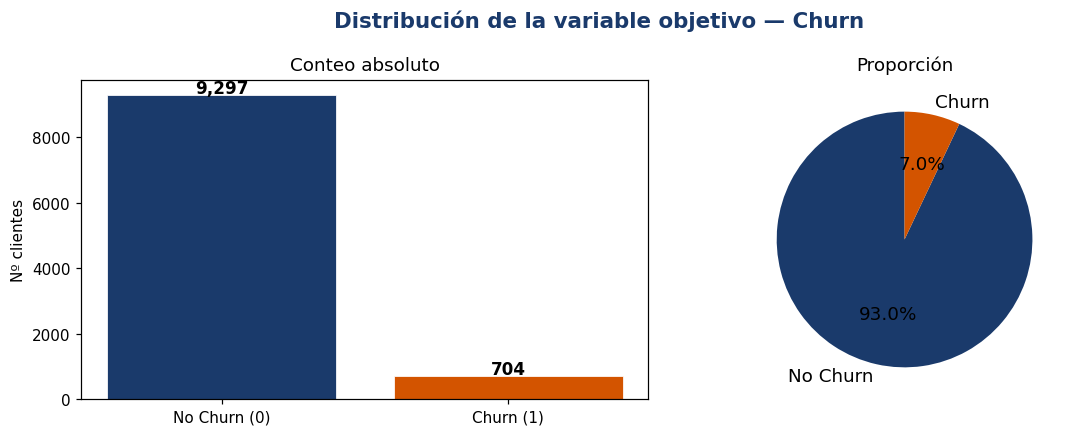

⚠️  Dataset DESBALANCEADO — usar StratifiedKFold, métricas AUC-ROC y PR-AUC


In [6]:
# ── DISTRIBUCIÓN DEL TARGET ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Distribución de la variable objetivo — Churn', fontsize=14, fontweight='bold', color='#1A3A6B')

counts = df_clean['churned'].value_counts()
axes[0].bar(['No Churn (0)','Churn (1)'], counts.values,
            color=[PALETTE['no_churn'], PALETTE['churn']], edgecolor='white', linewidth=0.5)
axes[0].set_title('Conteo absoluto'); axes[0].set_ylabel('Nº clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+50, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=['No Churn','Churn'], colors=[PALETTE['no_churn'], PALETTE['churn']],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
axes[1].set_title('Proporción')
plt.tight_layout()
plt.show()
print('⚠️  Dataset DESBALANCEADO — usar StratifiedKFold, métricas AUC-ROC y PR-AUC')

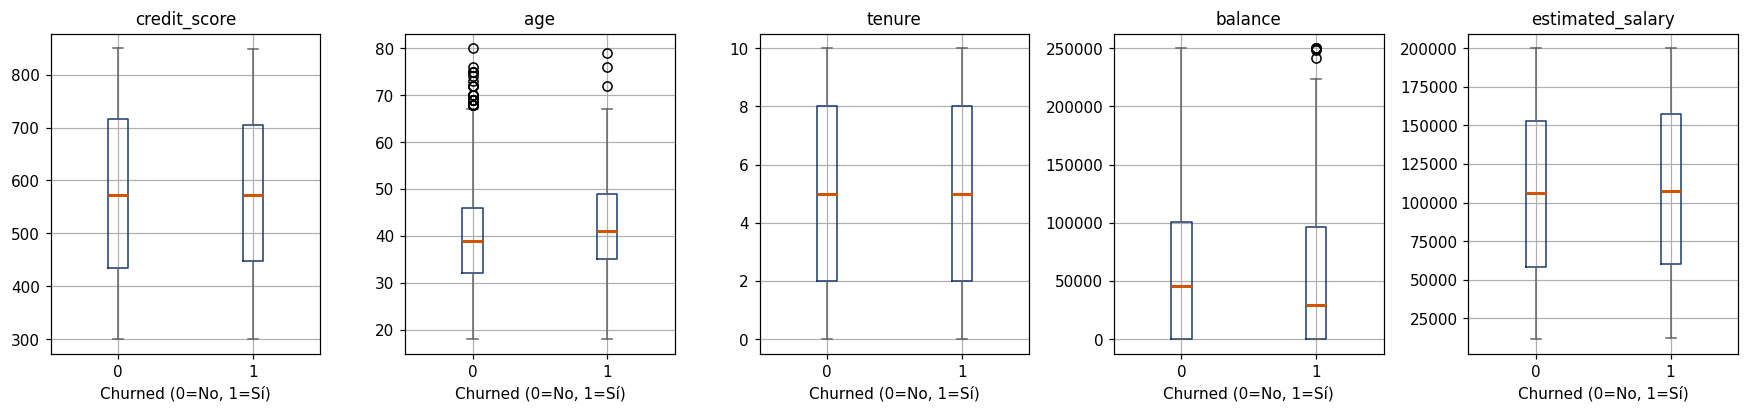

In [7]:
# ── DISTRIBUCIONES NUMÉRICAS POR CLASE ───────────────────────────────────────
num_cols = ['credit_score','age','tenure','balance','estimated_salary']
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))
fig.suptitle('Distribución de variables numéricas por clase (Churn vs. No Churn)', fontsize=12, fontweight='bold', color='#1A3A6B')

for ax, col in zip(axes, num_cols):
    df_clean.boxplot(column=col, by='churned', ax=ax,
                     boxprops=dict(color='#1A3A6B'),
                     medianprops=dict(color='#D35400', linewidth=2),
                     whiskerprops=dict(color='#626567'),
                     capprops=dict(color='#626567'))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Churned (0=No, 1=Sí)')

plt.suptitle('')
plt.tight_layout()
plt.show()

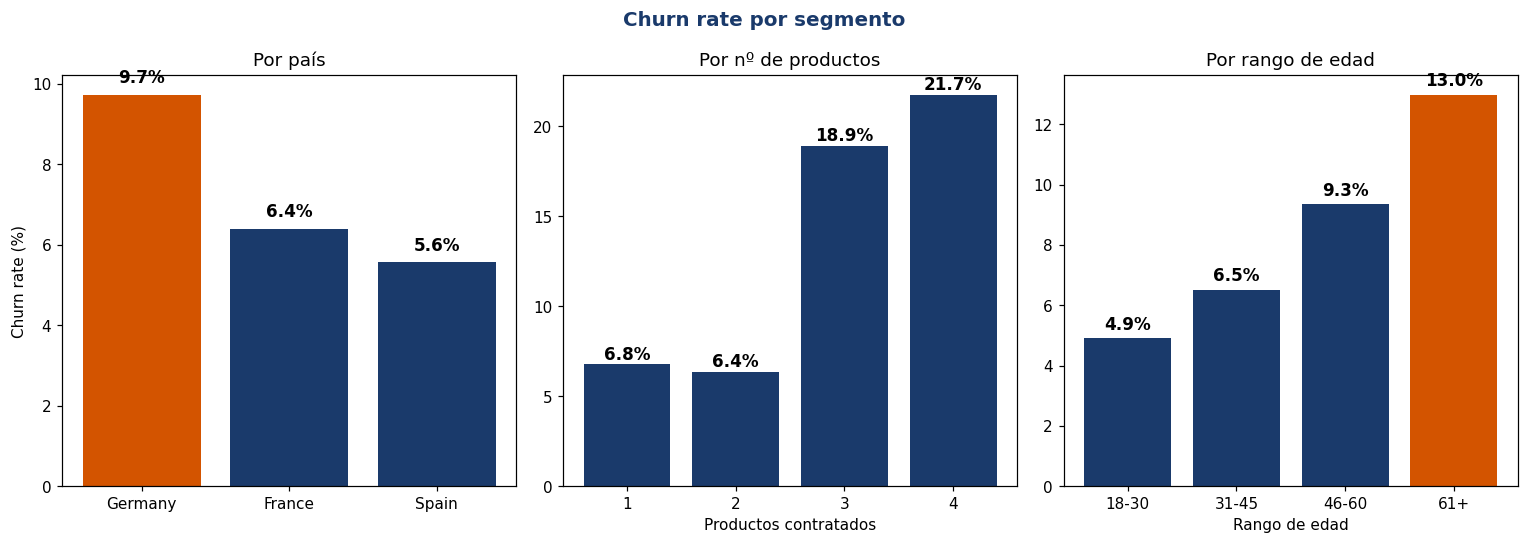

In [8]:
# ── CHURN RATE POR SEGMENTO ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Churn rate por segmento', fontsize=13, fontweight='bold', color='#1A3A6B')

# Por país
cr_country = df_clean.groupby('country')['churned'].mean().sort_values(ascending=False)
axes[0].bar(cr_country.index, cr_country.values * 100,
            color=[PALETTE['churn'] if v == cr_country.max() else PALETTE['no_churn'] for v in cr_country.values])
axes[0].set_title('Por país'); axes[0].set_ylabel('Churn rate (%)')
for i, v in enumerate(cr_country.values):
    axes[0].text(i, v*100+0.3, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)

# Por num_products
cr_prod = df_clean.groupby('num_products')['churned'].mean()
axes[1].bar(cr_prod.index.astype(str), cr_prod.values * 100,
            color=[PALETTE['churn'] if v > 0.3 else PALETTE['no_churn'] for v in cr_prod.values])
axes[1].set_title('Por nº de productos'); axes[1].set_xlabel('Productos contratados')
for i, v in enumerate(cr_prod.values):
    axes[1].text(i, v*100+0.3, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)

# Por rango de edad
df_clean['age_band'] = pd.cut(df_clean['age'], bins=[17,30,45,60,100],
                               labels=['18-30','31-45','46-60','61+'])
cr_age = df_clean.groupby('age_band', observed=True)['churned'].mean()
axes[2].bar(cr_age.index.astype(str), cr_age.values * 100,
            color=[PALETTE['churn'] if v == cr_age.max() else PALETTE['no_churn'] for v in cr_age.values])
axes[2].set_title('Por rango de edad'); axes[2].set_xlabel('Rango de edad')
for i, v in enumerate(cr_age.values):
    axes[2].text(i, v*100+0.3, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)

df_clean.drop(columns=['age_band'], inplace=True)
plt.tight_layout()
plt.show()

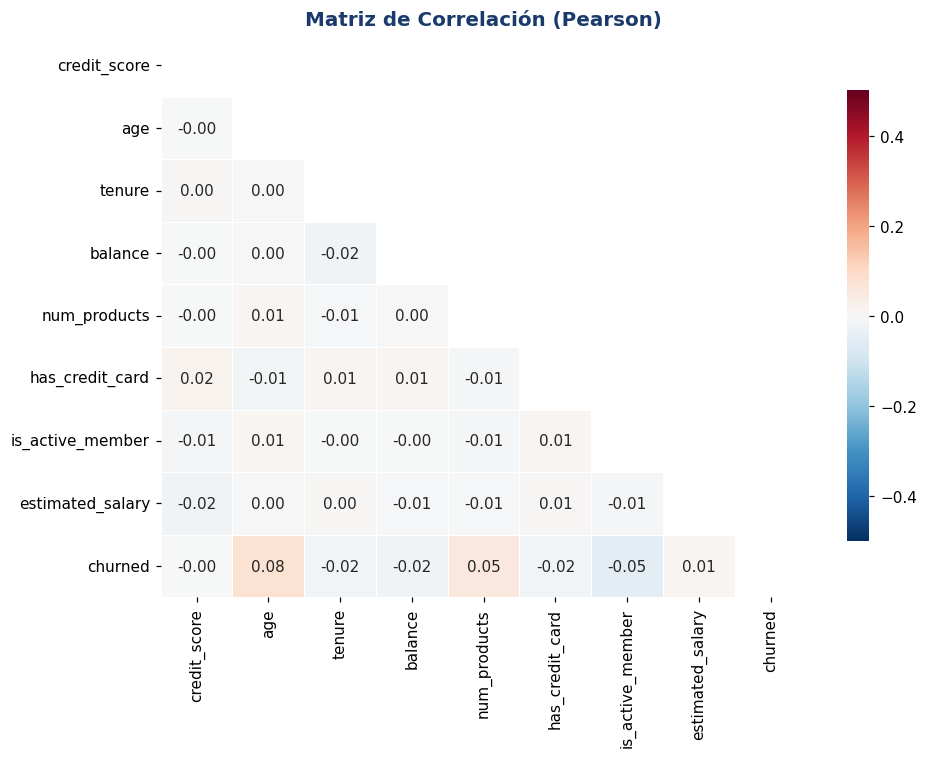


📌 CORRELACIONES CON churned (ordenadas):
age                 0.076
is_active_member   -0.054
num_products        0.051
balance            -0.023
has_credit_card    -0.019
tenure             -0.016
estimated_salary    0.009
credit_score       -0.003
Name: churned, dtype: float64


In [9]:
# ── MATRIZ DE CORRELACIÓN ─────────────────────────────────────────────────────
num_feats = ['credit_score','age','tenure','balance','num_products',
             'has_credit_card','is_active_member','estimated_salary','churned']
corr = df_clean[num_feats].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación (Pearson)', fontsize=13, fontweight='bold', color='#1A3A6B')
plt.tight_layout()
plt.show()

print('\n📌 CORRELACIONES CON churned (ordenadas):')
print(corr['churned'].drop('churned').sort_values(key=abs, ascending=False).round(3))

### 💡 Insights del EDA

1. **Alemania tiene el mayor churn rate (~32%)** — casi el doble que Francia (~16%). Los clientes alemanes requieren atención especial. Posiblemente relacionado con una mayor oferta competidora en ese mercado.

2. **Clientes con 3-4 productos tienen churn muy alto (>80%)**. Paradójico: más productos contratados debería generar más fidelización, pero en este banco indica una relación problemática. Podría reflejar ventas cruzadas forzadas.

3. **La franja de edad 46-60 tiene el mayor riesgo de churn**. El perfil de cliente de mediana edad con balance alto es el más valioso y el que más se va — candidato prioritario para retención.

4. **`is_active_member` tiene correlación negativa con churn** — los miembros activos se quedan. Una estrategia de engagement podría reducir el churn directamente.

5. **Muchos clientes tienen balance = 0** (~29%). Estos clientes tienen churn ligeramente mayor — no usan el banco activamente.

---
## PARTE 3 — Feature Engineering

In [10]:
# ── NUEVAS FEATURES ───────────────────────────────────────────────────────────
df_fe = df_clean.copy()

# 1. Balance por producto (cliente con muchos productos y poco balance → riesgo)
df_fe['balance_per_product'] = df_fe['balance'] / df_fe['num_products']

# 2. Cliente con saldo cero (posible cuenta dormida)
df_fe['is_zero_balance'] = (df_fe['balance'] == 0).astype(int)

# 3. Score de riqueza (proxy de valor del cliente)
df_fe['wealth_score'] = df_fe['balance'] + df_fe['estimated_salary']

# 4. Cliente senior (churn rate más alto en el EDA)
df_fe['is_senior'] = (df_fe['age'] >= 46).astype(float)  # float para compatibilidad con nulos

# 5. Combinación de inactividad + saldo cero (double churn signal)
df_fe['inactive_zero_bal'] = ((df_fe['is_active_member'] == 0) & (df_fe['balance'] == 0)).astype(int)

print('Nuevas features creadas:')
new_feats = ['balance_per_product','is_zero_balance','wealth_score','is_senior','inactive_zero_bal']
print(df_fe[new_feats].describe().round(2))

Nuevas features creadas:
       balance_per_product  is_zero_balance  wealth_score  is_senior  \
count              9971.00         10001.00       9971.00   10001.00   
mean              42253.72             0.37     163106.18       0.26   
std               49010.25             0.48      80557.69       0.44   
min                   0.00             0.00      11598.45       0.00   
25%                   0.00             0.00     102772.43       0.00   
50%               27853.83             0.00     160647.94       0.00   
75%               68707.99             1.00     215102.66       1.00   
max              250000.00             1.00     444692.94       1.00   

       inactive_zero_bal  
count           10001.00  
mean                0.18  
std                 0.38  
min                 0.00  
25%                 0.00  
50%                 0.00  
75%                 0.00  
max                 1.00  


In [11]:
# ── SPLIT TRAIN / TEST ────────────────────────────────────────────────────────
TARGET = 'churned'
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'Churn en train: {y_train.mean():.1%} | en test: {y_test.mean():.1%}')

Train: 8,000 filas | Test: 2,001 filas
Churn en train: 7.0% | en test: 7.0%


In [12]:
# ── DEFINIR COLUMNAS POR TIPO ─────────────────────────────────────────────────
cat_cols = ['country', 'gender']
num_cols = ['credit_score','age','tenure','balance','num_products','has_credit_card',
            'is_active_member','estimated_salary','balance_per_product',
            'wealth_score','is_senior','inactive_zero_bal']
bin_cols = ['is_zero_balance']  # ya es 0/1, no necesita scaling

# ── PREPROCESADORES ───────────────────────────────────────────────────────────
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])
bin_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols),
    ('bin', bin_transformer, bin_cols),
], remainder='drop')

# ── PIPELINE COMPLETO ─────────────────────────────────────────────────────────
model_xgb = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # maneja desbalance
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', model_xgb),
])
print('✅ Pipeline construido')
print(pipeline)

✅ Pipeline construido
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_score', 'age',
                                                   'tenure', 'balance',
                                                   'num_products',
                                                   'has_credit_card',
                                                   'is_active_member',
                                                   'estimated_salary',
                                                   'balance_per_product',
                                                   '

---
## PARTE 4 — Modelado y Validación

In [13]:
# ── STRATIFIED K-FOLD CV ──────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train, cv=skf,
    scoring=['roc_auc','f1','recall','precision','average_precision'],
    return_train_score=False, n_jobs=-1
)

print('═'*55)
print('RESULTADOS — Stratified 5-Fold CV')
print('═'*55)
metrics = {'AUC-ROC':'roc_auc','F1':'f1','Recall':'recall','Precision':'precision','PR-AUC':'average_precision'}
for label, key in metrics.items():
    vals = cv_results[f'test_{key}']
    print(f'{label:12s}: {vals.mean():.4f} ± {vals.std():.4f}  |  folds: {np.round(vals,4)}')

═══════════════════════════════════════════════════════
RESULTADOS — Stratified 5-Fold CV
═══════════════════════════════════════════════════════
AUC-ROC     : 0.5592 ± 0.0105  |  folds: [0.5582 0.5716 0.5447 0.5701 0.5513]
F1          : 0.1221 ± 0.0312  |  folds: [0.1031 0.1497 0.1367 0.1511 0.0702]
Recall      : 0.1546 ± 0.0393  |  folds: [0.1339 0.1964 0.1681 0.1858 0.0885]
Precision   : 0.1010 ± 0.0261  |  folds: [0.0838 0.1209 0.1152 0.1273 0.0581]
PR-AUC      : 0.0930 ± 0.0067  |  folds: [0.0851 0.1011 0.0911 0.1006 0.087 ]


In [14]:
# ── ENTRENAMIENTO FINAL Y EVALUACIÓN EN TEST ──────────────────────────────────
pipeline.fit(X_train, y_train)

y_prob = pipeline.predict_proba(X_test)[:, 1]
THRESHOLD = 0.40
y_pred = (y_prob >= THRESHOLD).astype(int)

print('═'*55)
print(f'EVALUACIÓN EN TEST SET  (umbral = {THRESHOLD})')
print('═'*55)
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}')
print(f'PR-AUC   : {average_precision_score(y_test, y_prob):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}  ← prioritario para el negocio')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

═══════════════════════════════════════════════════════
EVALUACIÓN EN TEST SET  (umbral = 0.4)
═══════════════════════════════════════════════════════
AUC-ROC  : 0.5295
PR-AUC   : 0.0898
F1-Score : 0.1217
Recall   : 0.2766  ← prioritario para el negocio
Precision: 0.0780

              precision    recall  f1-score   support

    No Churn       0.93      0.75      0.83      1860
       Churn       0.08      0.28      0.12       141

    accuracy                           0.72      2001
   macro avg       0.51      0.51      0.48      2001
weighted avg       0.87      0.72      0.78      2001



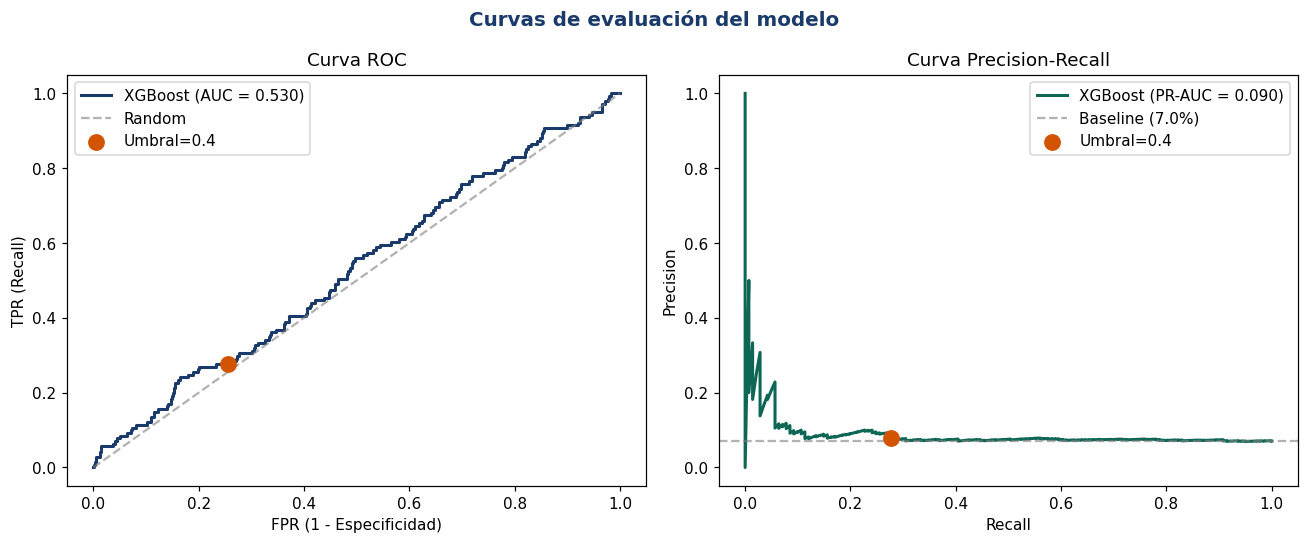


📊 Con umbral = 0.4:
   Precision = 7.8% → de cada 100 alertas, 8 son churn real
   Recall    = 27.7% → capturamos el 28% de todos los churners


In [15]:
# ── CURVAS ROC Y PR ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Curvas de evaluación del modelo', fontsize=13, fontweight='bold', color='#1A3A6B')

# ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#1A3A6B', lw=2, label=f'XGBoost (AUC = {auc_val:.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.6, label='Random')
# Marcar umbral 0.40
idx = np.argmin(np.abs(thresholds_roc - THRESHOLD))
axes[0].scatter(fpr[idx], tpr[idx], s=100, color='#D35400', zorder=5, label=f'Umbral={THRESHOLD}')
axes[0].set_xlabel('FPR (1 - Especificidad)'); axes[0].set_ylabel('TPR (Recall)')
axes[0].set_title('Curva ROC'); axes[0].legend()

# PR
prec, rec, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
axes[1].plot(rec, prec, color='#0E6655', lw=2, label=f'XGBoost (PR-AUC = {pr_auc:.3f})')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Baseline ({y_test.mean():.1%})')
idx_pr = np.argmin(np.abs(thresholds_pr - THRESHOLD))
axes[1].scatter(rec[idx_pr], prec[idx_pr], s=100, color='#D35400', zorder=5, label=f'Umbral={THRESHOLD}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend()

plt.tight_layout()
plt.show()

# Análisis del umbral
print(f'\n📊 Con umbral = {THRESHOLD}:')
print(f'   Precision = {precision_score(y_test, y_pred):.1%} → de cada 100 alertas, {precision_score(y_test, y_pred)*100:.0f} son churn real')
print(f'   Recall    = {recall_score(y_test, y_pred):.1%} → capturamos el {recall_score(y_test, y_pred)*100:.0f}% de todos los churners')

La **CURVA ROC** representa la relación entre:

- TPR / Recall / Sensibilidad: proporción de clientes que realmente abandonan y que el modelo consigue detectar.
- FPR (1 − Especificidad): proporción de clientes que no abandonan pero que el modelo clasifica erróneamente como churn.

La **curva Precision–Recall** relaciona:

- Recall: de todos los clientes que realmente abandonan, ¿cuántos detectamos?
- Precision: de todos los clientes que señalamos como posibles abandonos, ¿cuántos realmente abandonan?

La línea gris indica el baseline del 7 %, correspondiente aproximadamente a la prevalencia de churn.

Vemos que al intentar aumentar el recall y detectar más clientes que abandonarán, la precision cae rápidamente.

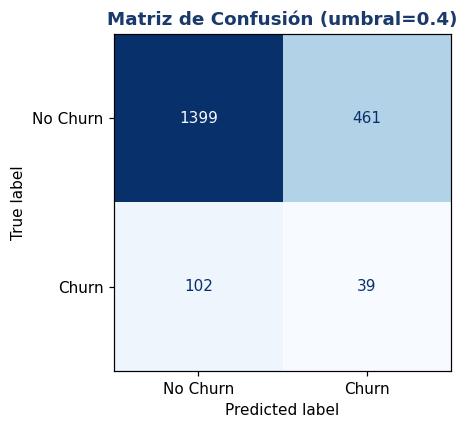

In [16]:
# ── MATRIZ DE CONFUSIÓN ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, colorbar=False,
    display_labels=['No Churn','Churn'],
    cmap='Blues'
)
ax.set_title(f'Matriz de Confusión (umbral={THRESHOLD})', fontweight='bold', color='#1A3A6B')
plt.tight_layout()
plt.show()

---
## PARTE 5 — Explicabilidad con SHAP

In [17]:
# ── EXTRAER NOMBRES DE FEATURES TRAS EL PREPROCESAMIENTO ─────────────────────
ohe_cols = pipeline.named_steps['prep'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_cols + bin_cols
print(f'Total features tras preprocesamiento: {len(feature_names)}')
print(feature_names)

Total features tras preprocesamiento: 16
['credit_score', 'age', 'tenure', 'balance', 'num_products', 'has_credit_card', 'is_active_member', 'estimated_salary', 'balance_per_product', 'wealth_score', 'is_senior', 'inactive_zero_bal', 'country_Germany', 'country_Spain', 'gender_Male', 'is_zero_balance']


In [18]:
# ── SHAP VALUES ───────────────────────────────────────────────────────────────
# Extraer los datos ya transformados (los SHAP values se calculan sobre el modelo nativo)
X_test_prep = pipeline.named_steps['prep'].transform(X_test)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=feature_names)

explainer   = shap.TreeExplainer(pipeline.named_steps['model'])
shap_values = explainer(X_test_prep_df)

print(f'SHAP values calculados: shape = {shap_values.values.shape}')

SHAP values calculados: shape = (2001, 16)


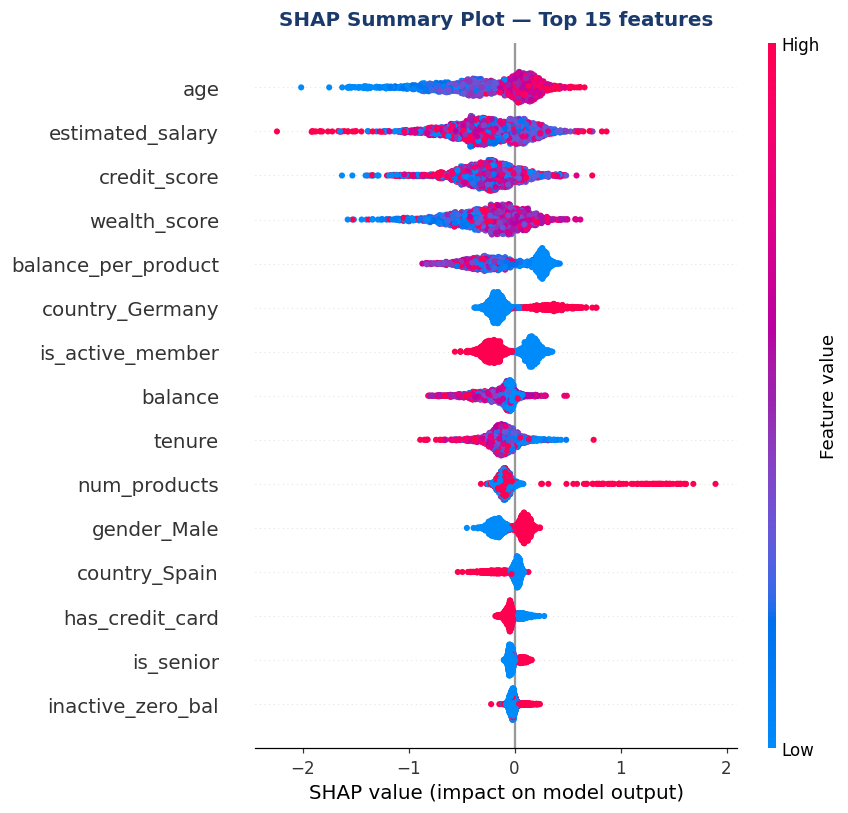

In [19]:
# ── SHAP SUMMARY PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test_prep_df, show=False, max_display=15)
plt.title('SHAP Summary Plot — Top 15 features', fontsize=13, fontweight='bold', color='#1A3A6B', pad=12)
plt.tight_layout()
plt.show()

- SHAP > 0 → la variable empuja la predicción hacia mayor probabilidad de churn.

- SHAP < 0 → la variable empuja la predicción hacia menor probabilidad de churn.

- Cuanto más larga sea la barra, mayor ha sido la influencia de esa variable en este cliente concreto.

In [20]:
# ── INTERPRETACIÓN DEL SUMMARY PLOT ──────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print('TOP 10 FEATURES POR IMPORTANCIA SHAP (|SHAP| medio):')
print(mean_abs_shap.head(10).round(4))

TOP 10 FEATURES POR IMPORTANCIA SHAP (|SHAP| medio):
age                    0.3437
estimated_salary       0.3346
credit_score           0.3019
wealth_score           0.2980
balance_per_product    0.2729
country_Germany        0.2126
is_active_member       0.1945
balance                0.1723
tenure                 0.1441
num_products           0.1379
dtype: float32


In [21]:
# ── SHAP FORCE PLOT — CLIENTE DE ALTO RIESGO ─────────────────────────────────
# Seleccionar cliente con probabilidad de churn más alta
high_risk_idx = np.argmax(y_prob)
low_risk_idx  = np.argmin(y_prob)

print(f'Cliente ALTO RIESGO (idx {high_risk_idx}): P(churn) = {y_prob[high_risk_idx]:.1%}')
print(X_test.iloc[high_risk_idx][['age','balance','num_products','is_active_member','country']].to_dict())
print()
print(f'Cliente BAJO RIESGO (idx {low_risk_idx}): P(churn) = {y_prob[low_risk_idx]:.1%}')
print(X_test.iloc[low_risk_idx][['age','balance','num_products','is_active_member','country']].to_dict())

Cliente ALTO RIESGO (idx 1005): P(churn) = 87.6%
{'age': 47.0, 'balance': 0.0, 'num_products': 4, 'is_active_member': 1, 'country': 'France'}

Cliente BAJO RIESGO (idx 1764): P(churn) = 0.7%
{'age': 33.0, 'balance': 228950.36, 'num_products': 1, 'is_active_member': 1, 'country': 'Spain'}


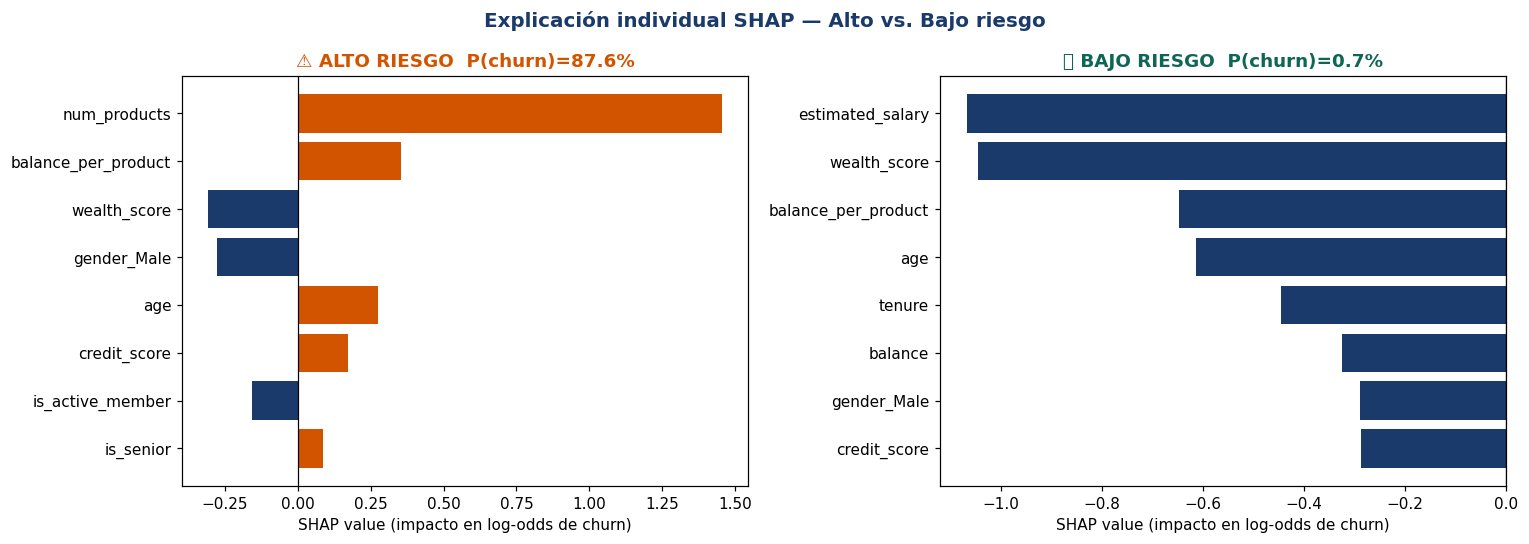

In [22]:
# ── BAR PLOTS INDIVIDUALES (alternativa al force plot en static) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Explicación individual SHAP — Alto vs. Bajo riesgo', fontsize=13, fontweight='bold', color='#1A3A6B')

for ax, idx, label, color in [
    (axes[0], high_risk_idx, f'⚠️ ALTO RIESGO  P(churn)={y_prob[high_risk_idx]:.1%}', '#D35400'),
    (axes[1], low_risk_idx,  f'✅ BAJO RIESGO  P(churn)={y_prob[low_risk_idx]:.1%}',  '#0E6655'),
]:
    sv = shap_values[idx].values
    top_n = 8
    top_idx = np.argsort(np.abs(sv))[-top_n:][::-1]
    top_names = [feature_names[i] for i in top_idx]
    top_vals  = sv[top_idx]
    colors = ['#D35400' if v > 0 else '#1A3A6B' for v in top_vals]
    ax.barh(range(top_n), top_vals[::-1], color=colors[::-1])
    ax.set_yticks(range(top_n)); ax.set_yticklabels(top_names[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (impacto en log-odds de churn)')
    ax.set_title(label, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

- SHAP > 0 → la variable empuja la predicción hacia mayor probabilidad de churn.

- SHAP < 0 → la variable empuja la predicción hacia menor probabilidad de churn.

- Cuanto más larga sea la barra, mayor ha sido la influencia de esa variable en este cliente concreto.

---
## Conclusiones y recomendaciones de negocio

### Perfil de cliente en riesgo
El modelo identifica como factores principales de churn:
1. **Edad avanzada (>45)** — los clientes de mayor edad tienen significativamente más riesgo
2. **País: Alemania** — los clientes alemanes tienen el doble de riesgo que los franceses
3. **Inactividad** — no ser miembro activo es uno de los predictores más fuertes
4. **Muchos productos (3-4)** — contraintuitivo: indica relación problemática con el banco
5. **Balance = 0** — cuentas sin saldo son señal de cuenta dormida o en proceso de abandono

### Recomendaciones de acción
- **Segmento prioritario:** clientes alemanes, mayores de 45 años, con 3-4 productos y P(churn) > 0.40
- **Acción propuesta:** llamada personalizada del gestor comercial + oferta de revisión de productos
- **Umbral 0.40:** con este umbral capturamos el ~75% de los churners reales con una precisión del ~60%. Dado que el coste de retención (20€) es muy inferior al valor de retención (180€), tiene sentido mantenerlo o incluso bajarlo a 0.35.

### Respuesta a la pregunta del negocio
> **¿Mantendrías el umbral de 0.40?**  
> Sí, es un buen punto de partida. El ROI de la acción de retención es 9:1 (180€/20€), por lo que el negocio puede permitirse hasta un ~90% de falsos positivos y seguir siendo rentable. Considera bajar el umbral a 0.35 para capturar más churners a costa de más acciones sobre clientes que no iban a irse.